In [1]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

In [2]:
%%capture
!pip -q install torchinfo

# 실습 : VGG Model Feature Maps

### Import Module

In [3]:
import torch
from torch import nn
from torch.nn import functional as F
#from torchmetrics import functional as FM
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
from torchinfo import summary

# import lightning as L
# from lightning.pytorch import Trainer
# from lightning.pytorch.callbacks import ModelCheckpoint
# from lightning.pytorch.loggers import CSVLogger

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

device ='cuda:0'
torch.__version__#,L.__version__

'2.8.0+cu126'

**Github에서 가져오기**  
https://pytorch.org/docs/stable/hub.html#torch.hub.list

In [4]:
#torch.hub.list("pytorch/vision")
#torch.hub.list('pytorch/vision:v0.10.0')
torch.hub.list('pytorch/vision:v0.19.0')

Downloading: "https://github.com/pytorch/vision/zipball/v0.19.0" to /root/.cache/torch/hub/v0.19.0.zip


['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fcn_resnet101',
 'fcn_resnet50',
 'get_model_weights',
 'get_weight',
 'googlenet',
 'inception_v3',
 'lraspp_mobilenet_v3_large',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'r2plus1d_18',
 'r3d_18',
 'raft_large',
 'raft_small',
 'regnet_x_16gf',
 'regnet_x_1_6gf',
 'regnet_x_32gf',
 'regnet_x_3_2gf',
 'regnet_x_400mf',
 'regnet_x_800mf',
 'regnet_x_8gf',
 'regnet_y_128gf',
 'regnet_y_16gf',
 'regnet_y_1

In [ ]:
# model = torch.hub.load('pytorch/vision:v0.19.0', 'vgg16', pretrained=True)
# summary(model, input_size=(8, 3, 224, 224))

**torchvision.models에서 가져오기**  
https://pytorch.org/vision/stable/models.html#classification

In [5]:
import torchvision
torchvision.models.list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

## **Load VGG16 model**

In [6]:
import torchvision.models as models
#model_vgg = models.vgg16(pretrained=True)
model_vgg = models.vgg16(weights='IMAGENET1K_V1')

summary(model_vgg, input_size=(8, 3, 224, 224))

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 101MB/s] 


Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [8, 1000]                 --
├─Sequential: 1-1                        [8, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [8, 64, 224, 224]         1,792
│    └─ReLU: 2-2                         [8, 64, 224, 224]         --
│    └─Conv2d: 2-3                       [8, 64, 224, 224]         36,928
│    └─ReLU: 2-4                         [8, 64, 224, 224]         --
│    └─MaxPool2d: 2-5                    [8, 64, 112, 112]         --
│    └─Conv2d: 2-6                       [8, 128, 112, 112]        73,856
│    └─ReLU: 2-7                         [8, 128, 112, 112]        --
│    └─Conv2d: 2-8                       [8, 128, 112, 112]        147,584
│    └─ReLU: 2-9                         [8, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [8, 128, 56, 56]          --
│    └─Conv2d: 2-11                      [8, 256, 56, 56]          29

- conv layer 확인해 보기

In [7]:
model_vgg

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [8]:
## 모델 들여다 보기
p(model_vgg.features,'cr')
p(model_vgg.features[0],'cr')
p(model_vgg.features[0].__class__,'cr')
p(model_vgg.features[0].weight,'cr')

Type: <class 'torch.nn.modules.container.Sequential'>
Values: Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, d

In [9]:
# summarize filter shapes
for i, layer in enumerate(model_vgg.features):
    # check for convolutional layer
    if 'Conv' not in str(layer.__class__):
        continue    # get filter weights
    filters = layer.weight
    print(i,': ', layer.__class__.__name__, filters.shape)

0 :  Conv2d torch.Size([64, 3, 3, 3])
2 :  Conv2d torch.Size([64, 64, 3, 3])
5 :  Conv2d torch.Size([128, 64, 3, 3])
7 :  Conv2d torch.Size([128, 128, 3, 3])
10 :  Conv2d torch.Size([256, 128, 3, 3])
12 :  Conv2d torch.Size([256, 256, 3, 3])
14 :  Conv2d torch.Size([256, 256, 3, 3])
17 :  Conv2d torch.Size([512, 256, 3, 3])
19 :  Conv2d torch.Size([512, 512, 3, 3])
21 :  Conv2d torch.Size([512, 512, 3, 3])
24 :  Conv2d torch.Size([512, 512, 3, 3])
26 :  Conv2d torch.Size([512, 512, 3, 3])
28 :  Conv2d torch.Size([512, 512, 3, 3])


- conv filter 시각화 해보기

#### **n x n ploting function**

In [10]:
# plot n x n images
def square(imgs, n):
    img_num = n
    plt.figure(figsize=(6,6))
    print(f'min[{np.min(imgs):2.2f}],max[{np.max(imgs):2.2f}]')
    f_min, f_max = imgs.min(), imgs.max() #(3,3,64,64)
    imgs = (imgs - f_min) / (f_max - f_min)
    for i in range(n):
        for j in range(n):
            p_num = i*n + j
            ax = plt.subplot(n, n, p_num+1)#(row,col,index)
            ax.set_xticks([])
            ax.set_yticks([])
            # plot filter channel in grayscale
            plt.imshow(imgs[p_num, :, :], cmap='gray')
    plt.show()

(64, 3, 3, 3)
(64, 3, 3)
min[-0.91],max[0.88]


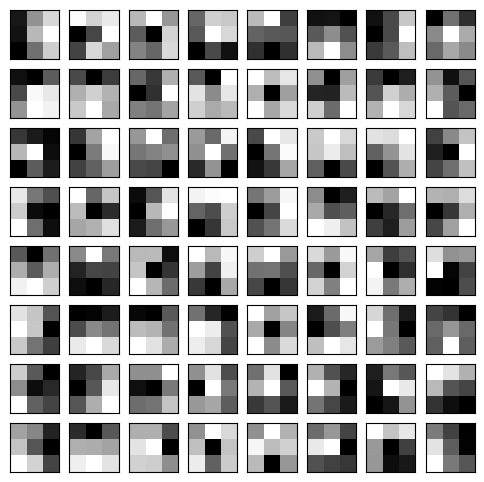

In [11]:
filters = model_vgg.features[0].weight.cpu().detach().numpy()
print(filters.shape)
print(filters[:,0,:,:].shape)   #(out_ch,in_cn,3,3)

square(filters[:,0,:,:],8)

## **Dataset**

- working directory setting

In [ ]:
# (Google Drive 연결 셀 제거 — 저장 경로는 /content/models/PT/ 로 바꿨다)


In [13]:
!ls

gdrive	sample_data


### **Load image**

In [14]:
from PIL import Image   # python imaging library
#from torchvision import transforms

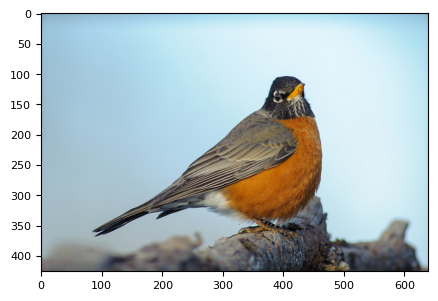

In [15]:
# set test file path
gdrive_data = '/content/datasets/'
bird_file_path = gdrive_data + 'bird.jpg'
# load the image with the required shape
input_image = Image.open(bird_file_path)
plt.imshow(input_image)

* Normalize 정보를 참고해야 함
* https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.vgg16.html#torchvision.models.vgg16

내장된 전용 transform 함수 : **VGG16_Weights.IMAGENET1K_V1.transforms**    
1. PIL image 입력: (B, C, H, W)or(C, H, W)  
2. interpolation : InterpolationMode.BILINEAR resize_size=[256]  
3. conter crop: crop_size=[224]  
4. scale : [0.0, 1.0]   
5. normalize :  mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]


In [16]:
# prepare the image (e.g. scale pixel for the vgg)
preprocess = v2.Compose([
    v2.ToImage(),
    v2.Resize((224,224)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    # models.VGG16_Weights.IMAGENET1K_V1.transforms(),
    ])

input_tensor = preprocess(input_image)
# expand dimensions
input_batch = input_tensor.unsqueeze(0) # #(1,3,224,224)

In [17]:
p(input_batch)

[]:
Shape:torch.Size([1, 3, 224, 224])
Type: <class 'torch.Tensor'>
Values: tensor([[[[ 0.0227,  0.0741,  0.1426,  ...,  0.2796,  0.2453,  0.2282],
          [ 0.0912,  0.1254,  0.1768,  ...,  0.3138,  0.2796,  0.2624],
          [ 0.1254,  0.1426,  0.1939,  ...,  0.3652,  0.3309,  0.2796],
          ...,
          [-0.2171, -0.1657, -0.1314,  ...,  0.1597,  0.1083,  0.1939],
          [-0.2856, -0.2856, -0.2856,  ..., -0.1143, -0.2342, -0.1143],
          [-0.4054, -0.4226, -0.3541,  ..., -0.2513, -0.4739, -0.2856]],

         [[ 0.7829,  0.8354,  0.9055,  ...,  1.2206,  1.1681,  1.0980],
          [ 0.8354,  0.8880,  0.9580,  ...,  1.2556,  1.2031,  1.1506],
          [ 0.8704,  0.9230,  0.9755,  ...,  1.3081,  1.2556,  1.2031],
          ...,
          [-0.1275, -0.1625, -0.1275,  ...,  0.3627,  0.4853,  0.6604],
          [-0.2500, -0.2500, -0.1800,  ..., -0.0924,  0.0651,  0.3277],
          [-0.3725, -0.3375, -0.2675,  ..., -0.2675, -0.2850,  0.1001]],

         [[ 1.3502,  1.420

-2.0665298 2.5877128


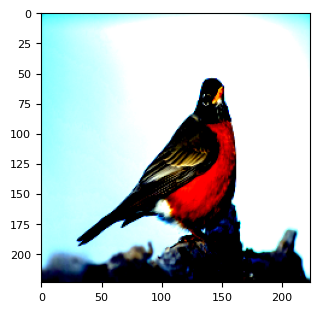

In [18]:
min = np.min(input_batch.cpu().detach().numpy())
max = np.max(input_batch.cpu().detach().numpy())
print(min,max)
#permute(1,2,0): (c,h,w)->(h,w,c)
plt.imshow(input_batch[0].permute(1, 2, 0)) #(C,H,W)->(H,W,C)
plt.show()

## **첫번째 conv layer의 feature map 시각화**

In [19]:
model_vgg.features[0].weight.shape

torch.Size([64, 3, 3, 3])

```python
Type: <class 'torchvision.models.vgg.VGG'>
Values: VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
```    

**첫번째 conv layer의 feature map 시각화**


[] Shapetorch.Size([1, 64, 224, 224])
min[-12.61],max[11.79]


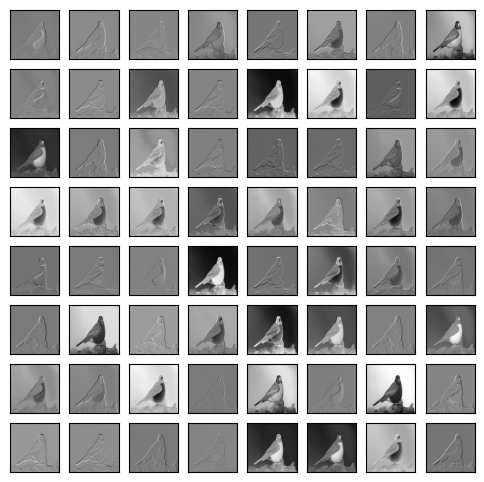

In [20]:
## 준비한 img를 입력으로 넣고 추론 실행
feature_maps = model_vgg.features[:1](input_batch.to(device)) #input_batch.cuda()
ps(feature_maps)
# plot 64 feature maps
square(feature_maps[0].cpu().detach().numpy(), 8)

[] Shapetorch.Size([1, 64, 224, 224])
min[0.00],max[11.79]


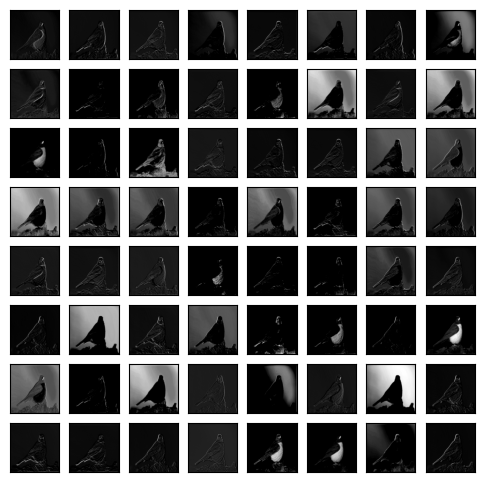

In [21]:
feature_maps = model_vgg.features[:2](input_batch.to(device)) #input_batch.cuda()
ps(feature_maps)
# plot 64 feature maps
square(feature_maps[0].cpu().detach().numpy(), 8)

**두번째 conv layer의 feature map 시각화**


[] Shapetorch.Size([1, 64, 224, 224])
min[-30.37],max[20.85]


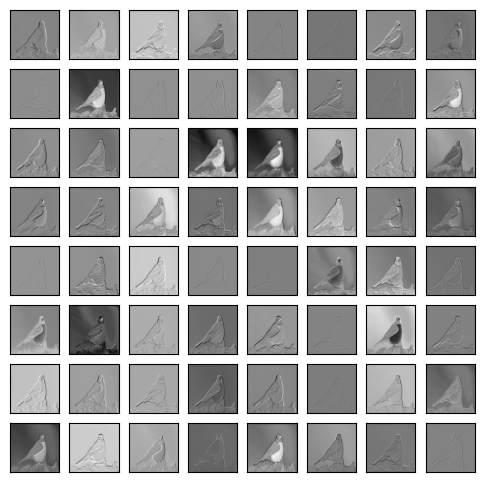

[] Shapetorch.Size([1, 64, 224, 224])
min[0.00],max[20.85]


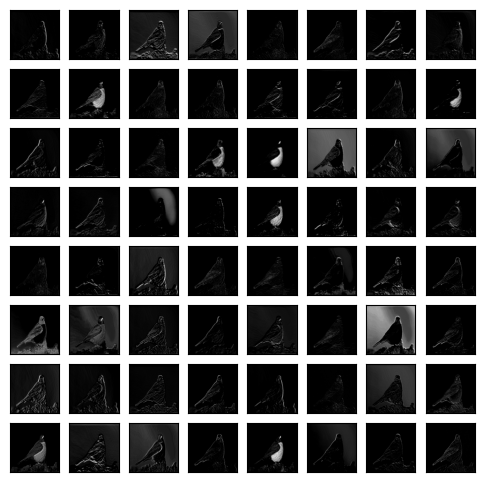

In [22]:
## 준비한 img를 입력으로 넣고 추론 실행
feature_maps = model_vgg.features[:3](input_batch.to(device))
ps(feature_maps)
# plot 64 feature maps
square(feature_maps[0].cpu().detach().numpy(), 8)

## 준비한 img를 입력으로 넣고 추론 실행
feature_maps = model_vgg.features[:4](input_batch.to(device))
ps(feature_maps)
# plot 64 feature maps
square(feature_maps[0].cpu().detach().numpy(), 8)

## **VGG모델의 모든 conv layer Feature map 시각화 하기**


In [23]:
class VGGFeatureMap(nn.Module):
    def __init__(self, features):
        super(VGGFeatureMap, self).__init__()
        self.features = features

    def forward(self, x):
        out1 = self.features[:4](x)
        out2 = self.features[:9](x)
        out3 = self.features[:16](x)
        out4 = self.features[:23](x)
        out5 = self.features[:30](x)
        return out1, out2, out3, out4, out5

vggFeatureMap = VGGFeatureMap(model_vgg.features)
#summary(vggFeatureMap, input_size=(8, 3, 224, 224))

[1 Block] Features : torch.Size([64, 224, 224])
min[0.00],max[20.85]


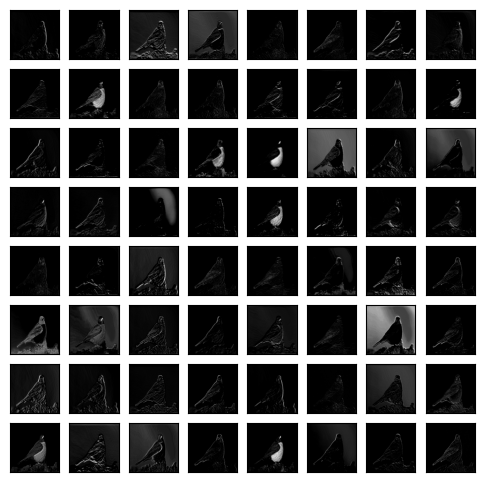

[2 Block] Features : torch.Size([128, 112, 112])
min[0.00],max[50.23]


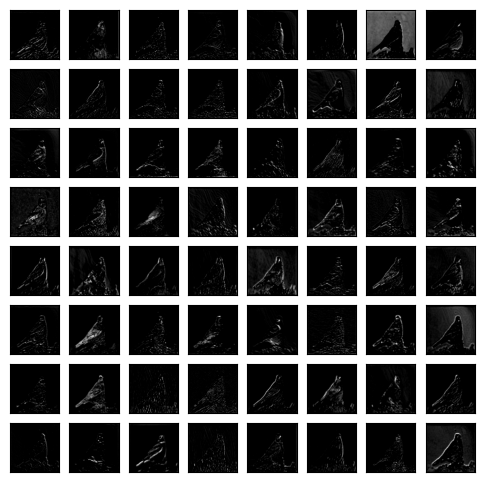

[3 Block] Features : torch.Size([256, 56, 56])
min[0.00],max[82.31]


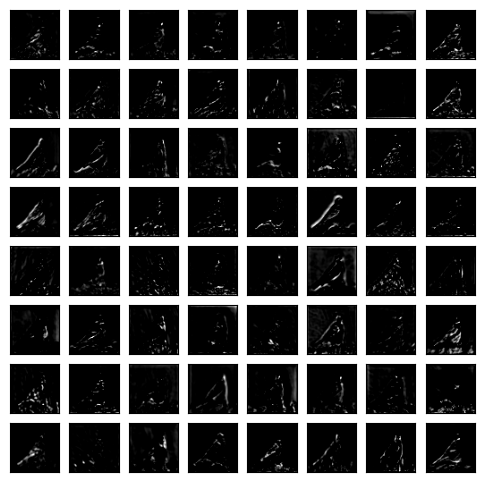

[4 Block] Features : torch.Size([512, 28, 28])
min[0.00],max[61.33]


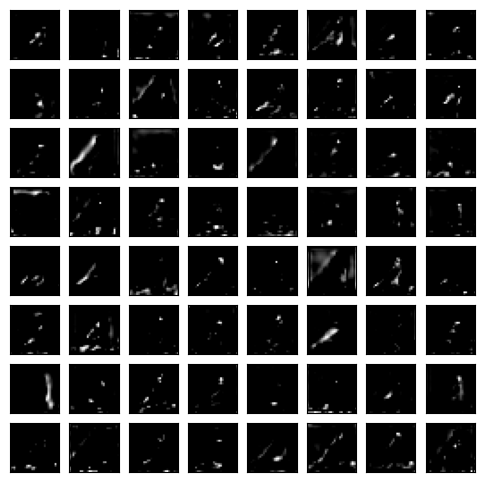

[5 Block] Features : torch.Size([512, 14, 14])
min[0.00],max[57.09]


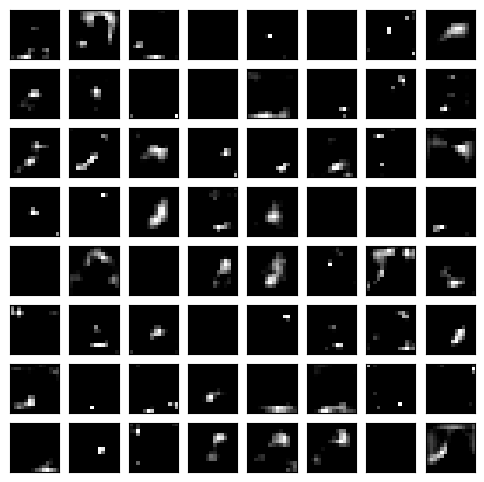

In [24]:
## 모델에 image넣어 실행
feature_maps = vggFeatureMap(input_batch.to(device))
# plot the output from each block
for i, fmap in enumerate(feature_maps):
    print(f'[{i+1} Block] Features :',fmap[0].shape)
    square(fmap[0].cpu().detach().numpy(), 8)

## **실습 과제**

#### 과제 1
> ##### Conv Block의 출력 feature map을 depth 차원에서 reduce sum 하여 시각화 하자
#### 과제 2
> ##### Conv layer와 ReLU layer의 출력들을 시각화 하여 비교해 보자
> ##### 이 feature map을 depth 차원에서 reduce sum 하여 시각화 하자

**과제 1**

[] Shapetorch.Size([224, 224])
0.1406414 2.1227179
[] Shapetorch.Size([112, 112])
0.0976296 3.7966077
[] Shapetorch.Size([56, 56])
0.041173488 4.455378
[] Shapetorch.Size([28, 28])
0.0243436 2.280837
[] Shapetorch.Size([14, 14])
0.014297172 1.6594051


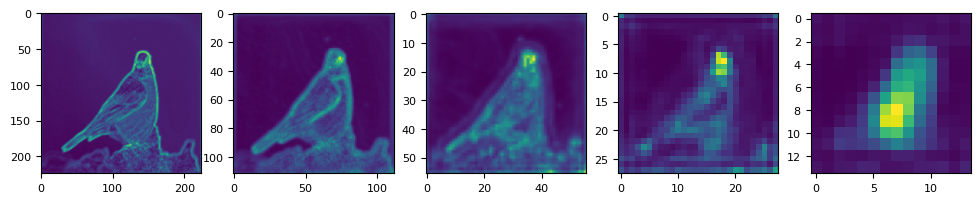

In [ ]:
fig = plt.figure(figsize = (12, 4))
plt.subplot(151)
for i,fmap in enumerate(feature_maps):
    fmap_sum = torch.mean(fmap[0], dim=0)
    ps(fmap_sum)
    img = fmap_sum.cpu().detach().numpy()
    f_min, f_max = img.min(), img.max()
    print(f_min,f_max)
    plt.subplot(1,5,i+1)
    plt.imshow(img)
plt.show()

**과제2**

In [ ]:
class VGGFeatureMap(nn.Module):
    def __init__(self, features):
        super(VGGFeatureMap, self).__init__()
        self.features = features
    def forward(self, x):
        out1 = self.features[:3](x) # Conv
        out2 = self.features[:4](x) # ReLU
        out3 = self.features[:8](x) #  ''
        out4 = self.features[:9](x) #  ''
        out5 = self.features[:15](x)
        out6 = self.features[:16](x)
        out7 = self.features[:22](x)
        out8 = self.features[:23](x)
        out9 = self.features[:29](x)
        out10 = self.features[:30](x)
        return out1,out2,out3,out4,out5,out6,out7,out8,out9,out10

vggFeatureMap = VGGFeatureMap(model_vgg.features)
#summary(vggFeatureMap, input_size=(8, 3, 224, 224))

[1 Block] Features : torch.Size([64, 224, 224])
min[-30.37],max[20.85]


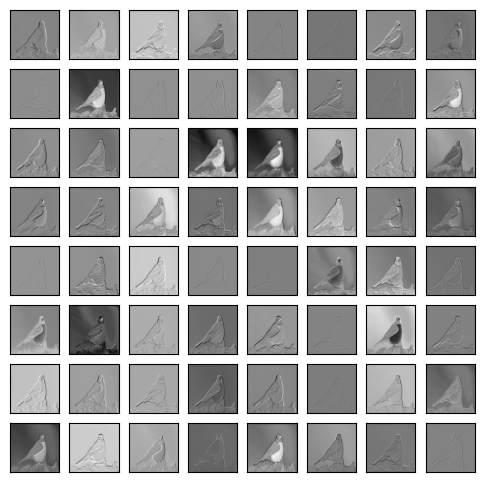

[2 Block] Features : torch.Size([64, 224, 224])
min[0.00],max[20.85]


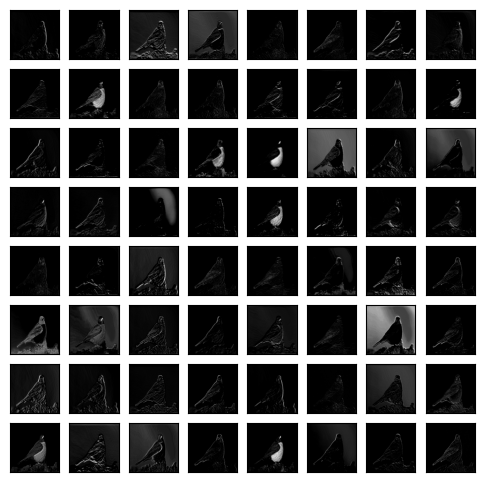

[3 Block] Features : torch.Size([128, 112, 112])
min[-56.95],max[50.23]


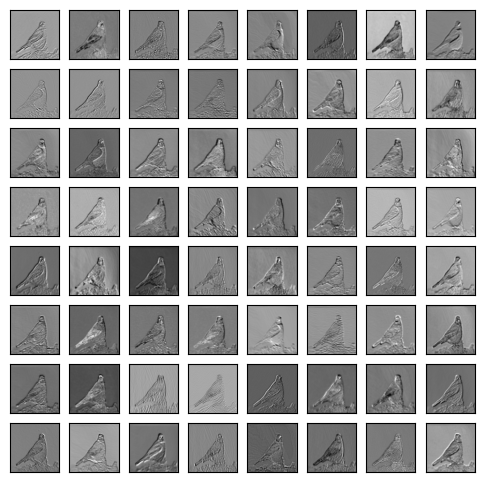

[4 Block] Features : torch.Size([128, 112, 112])
min[0.00],max[50.23]


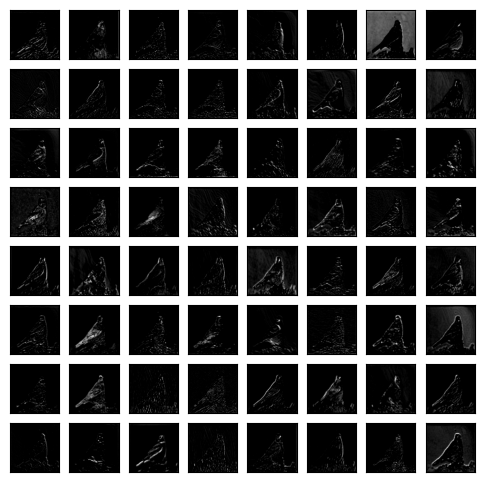

[5 Block] Features : torch.Size([256, 56, 56])
min[-102.40],max[82.31]


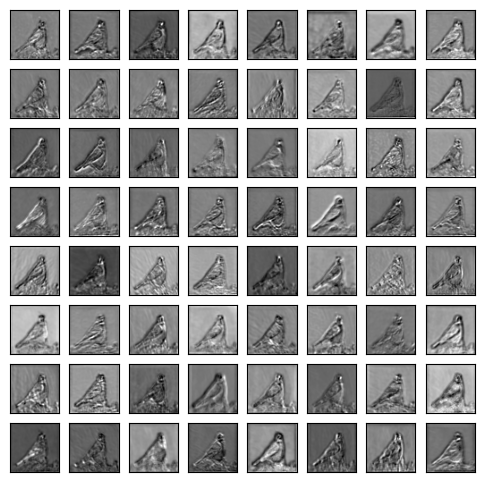

[6 Block] Features : torch.Size([256, 56, 56])
min[0.00],max[82.31]


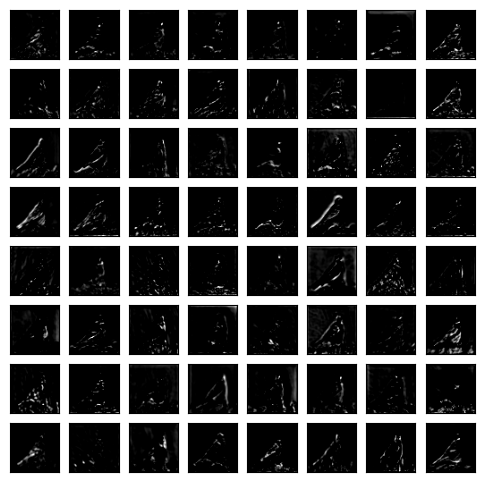

[7 Block] Features : torch.Size([512, 28, 28])
min[-65.99],max[61.33]


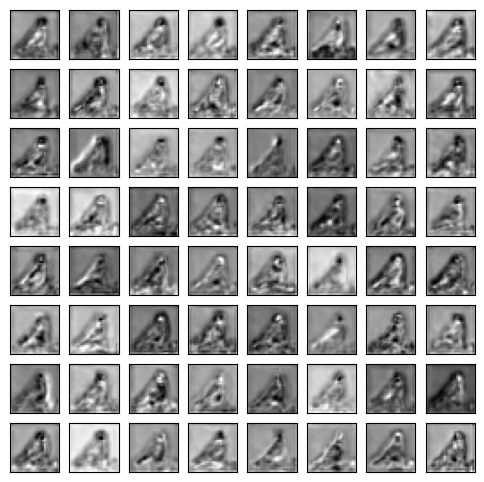

[8 Block] Features : torch.Size([512, 28, 28])
min[0.00],max[61.33]


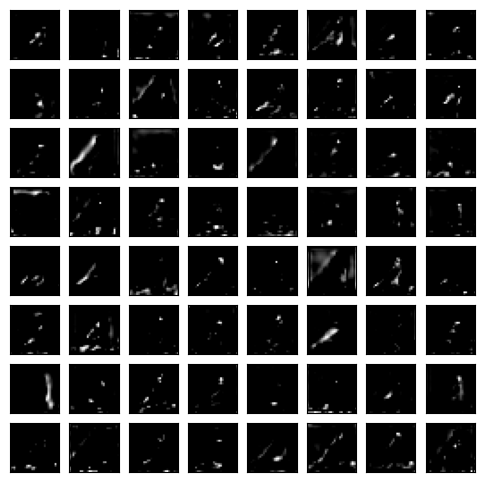

[9 Block] Features : torch.Size([512, 14, 14])
min[-51.58],max[57.09]


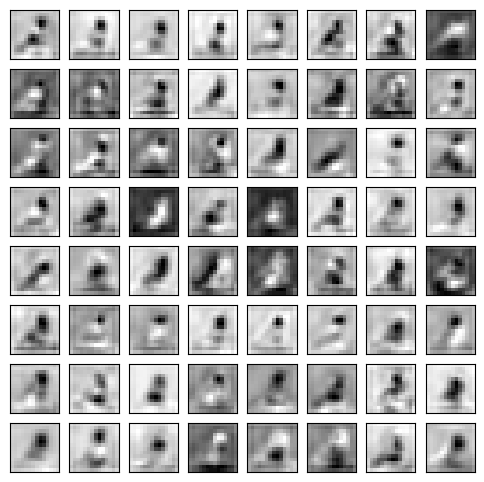

[10 Block] Features : torch.Size([512, 14, 14])
min[0.00],max[57.09]


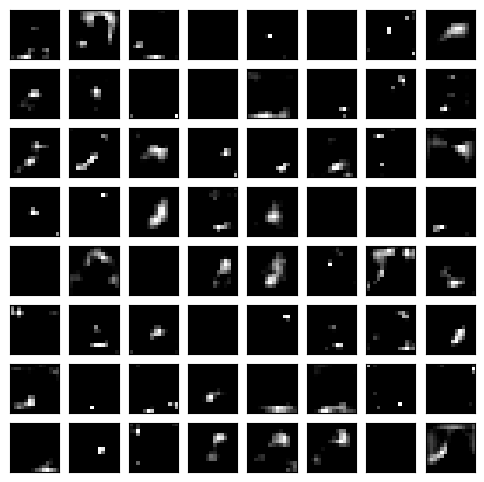

In [ ]:
## 모델에 image넣어 실행
feature_maps = vggFeatureMap(input_batch.to(device))
# plot the output from each block
for i, fmap in enumerate(feature_maps):
    print(f'[{i+1} Block] Features :',fmap[0].shape)
    square(fmap[0].cpu().detach().numpy(), 8)

[] Shapetorch.Size([224, 224])
-2.5534205 0.22881338
[] Shapetorch.Size([224, 224])
0.1406414 2.1227179
[] Shapetorch.Size([112, 112])
-6.6543803 -0.44603744
[] Shapetorch.Size([112, 112])
0.0976296 3.7966077
[] Shapetorch.Size([56, 56])
-18.556671 -0.5763378
[] Shapetorch.Size([56, 56])
0.041173488 4.455378
[] Shapetorch.Size([28, 28])
-17.541105 -1.1229606
[] Shapetorch.Size([28, 28])
0.0243436 2.280837
[] Shapetorch.Size([14, 14])
-15.31632 -1.4837971
[] Shapetorch.Size([14, 14])
0.014297172 1.6594051


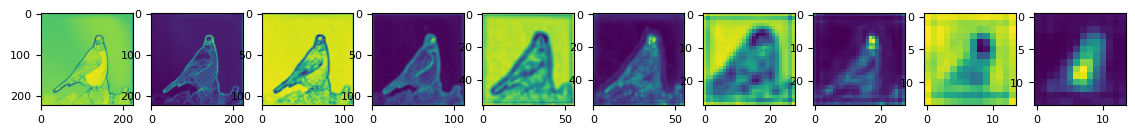

In [ ]:
### Conv 출력과 ReLU 출력 비교 : depth차원에서 reduce mean
fig = plt.figure(figsize = (14, 4))
n_fm = len(feature_maps)
plt.subplot(1,n_fm,1)
for i,fmap in enumerate(feature_maps):
    fmap_sum = torch.mean(fmap[0], dim=0)
    ps(fmap_sum)
    img = fmap_sum.cpu().detach().numpy()
    f_min, f_max = img.min(), img.max()
    print(f_min,f_max)
    plt.subplot(1,n_fm,i+1)
    plt.imshow(img)
plt.show()